In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import scipy.optimize as sco
from scipy.optimize import minimize

# ==========================================
# 1. CSV 파일에서 로그 수익률 데이터 불러오기
# ==========================================
returns = pd.read_csv("/Users/gobyeongho/Desktop/RL/etf_log_Returns(2012 start).csv", index_col="Date", parse_dates=True)

print(f"   데이터 로드 완료!")
print(f"   기간: {returns.index[0].strftime('%Y-%m-%d')} ~ {returns.index[-1].strftime('%Y-%m-%d')}")
print(f"   자산 수: {len(returns.columns)}개")
print(f"   데이터 포인트: {len(returns)}일")

# 자산 목록 (CSV 컬럼명에서 자동 추출)
assets = returns.columns.tolist()
print("\n[자산 목록]")
print(assets)

   데이터 로드 완료!
   기간: 2012-02-02 ~ 2026-04-03
   자산 수: 14개
   데이터 포인트: 3412일

[자산 목록]
['semicon', 'bank', 'car', 'finance', 'treasury3', 'ener&chem', 'iron', 'wti', 'gold', 'copper', 'necessities', 'healthcare', 'silver', 'treasury10']


In [ ]:
# ==========================================
# 2. 연간 공분산 행렬 계산
# ==========================================
cov_matrix = returns.cov() * 252  # 연환산

print("\n 연간 공분산 행렬 계산 완료")


✅ 연간 공분산 행렬 계산 완료



상관계수 히트맵을 그리는 중입니다...


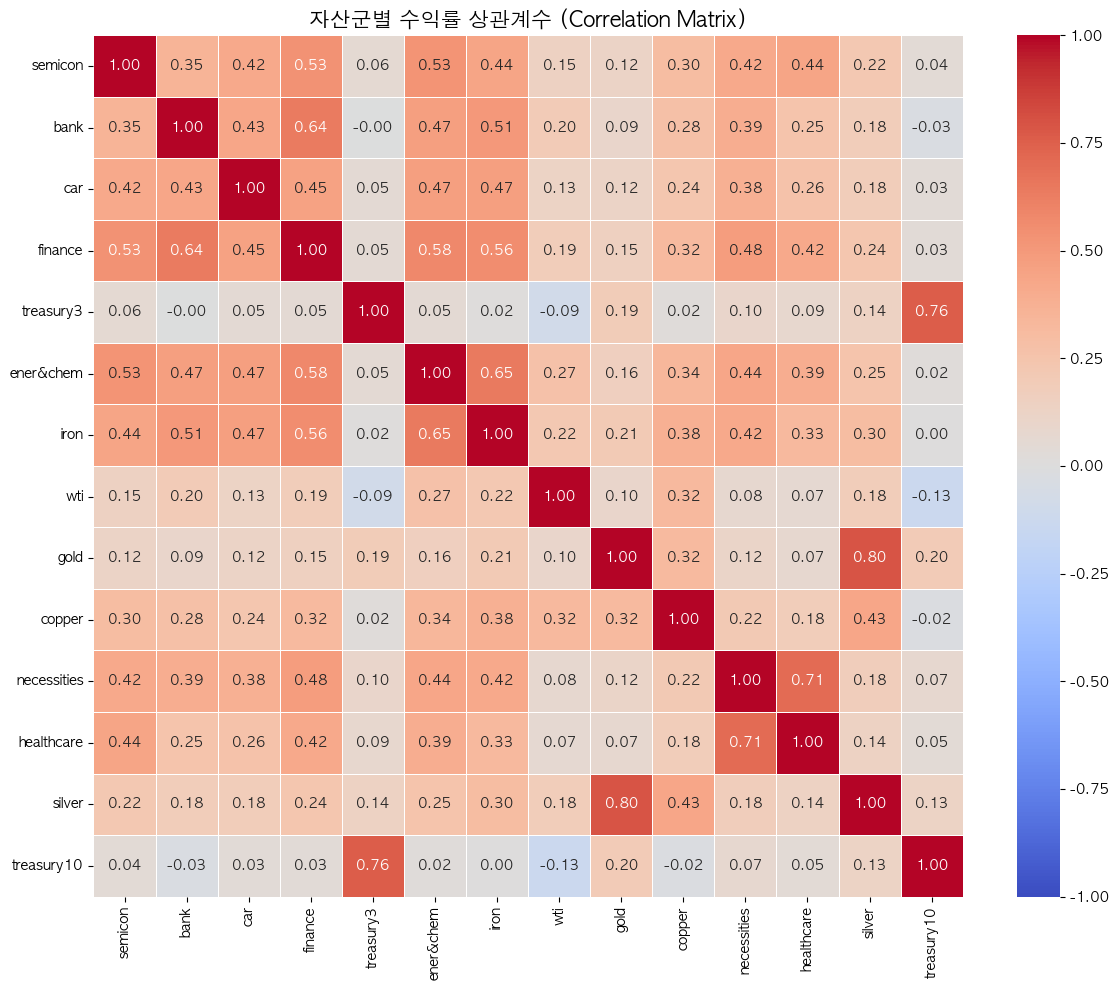

In [3]:
# ==========================================
# 3. 상관계수 히트맵 시각화
# ==========================================
correlation_matrix = returns.corr()

print("\n상관계수 히트맵을 그리는 중입니다...")

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title("자산군별 수익률 상관계수 (Correlation Matrix)", fontsize=15)
plt.tight_layout()
plt.show()

In [4]:
# ==========================================
# 4. 리스크 패리티 최적화
# ==========================================
def calculate_risk_contribution(weights, cov_matrix):
    """각 자산의 리스크 기여도를 계산하는 함수"""
    port_var = np.dot(weights.T, np.dot(cov_matrix, weights))
    port_std = np.sqrt(port_var)
    mrc = np.dot(cov_matrix, weights)
    rc = weights * mrc / port_std
    return rc

def risk_parity_objective(weights, cov_matrix):
    """리스크 기여도의 분산을 최소화하는 목적 함수"""
    rc = calculate_risk_contribution(weights, cov_matrix)
    rc_target = np.mean(rc)
    return np.sum(np.square(rc - rc_target))

num_assets = len(assets)
initial_weights = np.array([1 / num_assets] * num_assets)

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0})
bounds = tuple((0.0, 1.0) for _ in range(num_assets))

print("\n리스크 패리티 가중치를 계산하는 중입니다...")
result = minimize(risk_parity_objective, initial_weights, args=(cov_matrix.values,),
                  method='SLSQP', bounds=bounds, constraints=constraints)

optimal_weights = result.x

weights_df = pd.DataFrame({
    '자산군': assets,
    '비중(%)': optimal_weights * 100
})
weights_df = weights_df.sort_values(by='비중(%)', ascending=False).reset_index(drop=True)

print("\n[리스크 패리티 포트폴리오 최적 비중]")
print(weights_df.to_string(formatters={'비중(%)': '{:.2f}%'.format}))


리스크 패리티 가중치를 계산하는 중입니다...

[리스크 패리티 포트폴리오 최적 비중]
            자산군  비중(%)
0    treasury10 31.80%
1     treasury3 27.15%
2          gold  6.09%
3   necessities  4.30%
4        copper  4.14%
5           wti  3.70%
6          bank  3.50%
7           car  3.32%
8    healthcare  3.20%
9       semicon  2.84%
10    ener&chem  2.64%
11         iron  2.62%
12       silver  2.50%
13      finance  2.21%


In [5]:
# ==========================================
# 5. 개별 자산의 연환산 변동성(리스크) 계산
# ==========================================
print("\n[개별 자산 연환산 변동성 (리스크)]")
print("※ 수치가 높을수록 1년 동안 위아래로 움직이는 폭이 큰 위험 자산입니다.\n")

asset_volatilities = np.sqrt(np.diag(cov_matrix))

volatility_df = pd.DataFrame({
    '자산군': assets,
    '연환산 변동성(%)': asset_volatilities * 100
})
volatility_df = volatility_df.sort_values(by='연환산 변동성(%)', ascending=False).reset_index(drop=True)
print(volatility_df.to_string(formatters={'연환산 변동성(%)': '{:.2f}%'.format}))


[개별 자산 연환산 변동성 (리스크)]
※ 수치가 높을수록 1년 동안 위아래로 움직이는 폭이 큰 위험 자산입니다.

            자산군 연환산 변동성(%)
0           wti     35.31%
1        silver     31.55%
2       finance     29.65%
3    healthcare     29.25%
4       semicon     28.81%
5          iron     27.11%
6     ener&chem     27.08%
7           car     25.50%
8          bank     24.33%
9        copper     22.99%
10  necessities     17.18%
11         gold     16.90%
12   treasury10      5.53%
13    treasury3      1.73%


In [6]:
# ==========================================
# 6. 연평균 기대수익률 계산
# ==========================================
expected_returns = returns.mean() * 252

print("\n[연평균 기대수익률]")
expected_returns_df = pd.DataFrame({
    '자산군': assets,
    '연평균 수익률(%)': expected_returns.values * 100
}).sort_values(by='연평균 수익률(%)', ascending=False).reset_index(drop=True)

print(expected_returns_df.to_string(formatters={'연평균 수익률(%)': '{:.2f}%'.format}))


[연평균 기대수익률]
            자산군 연평균 수익률(%)
0       semicon     14.99%
1       finance     11.68%
2    healthcare     10.73%
3          bank      7.98%
4          gold      5.88%
5   necessities      4.86%
6           car      4.69%
7        silver      3.62%
8          iron      3.46%
9     ener&chem      2.69%
10    treasury3      2.30%
11   treasury10      2.05%
12       copper      0.87%
13          wti     -2.80%


In [ ]:
# ==========================================
# 7. 최대 샤프 지수 포트폴리오 (역사적 수익률 기반)
# ==========================================
rf_rate = 0.0249  # 무위험 수익률 (3년 국고채 기준)

def negative_sharpe(weights, expected_returns, cov_matrix, rf_rate):
    port_return = np.sum(weights * expected_returns)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (port_return - rf_rate) / port_volatility
    return -sharpe_ratio

print("\n최대 샤프 지수 포트폴리오를 계산하는 중입니다...")
expected_returns_array = expected_returns.values

result_sharpe = sco.minimize(
    negative_sharpe,
    initial_weights,
    args=(expected_returns_array, cov_matrix.values, rf_rate),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimal_weights_sharpe = result_sharpe.x

sharpe_weights_df = pd.DataFrame({
    '자산군': assets,
    '기대수익률(%)': expected_returns_array * 100,
    '비중(%)': optimal_weights_sharpe * 100
})
sharpe_weights_df = sharpe_weights_df.sort_values(by='비중(%)', ascending=False).reset_index(drop=True)

print("\n[최대 샤프 지수 포트폴리오 비중]")
print(sharpe_weights_df.to_string(formatters={
    '기대수익률(%)': '{:.2f}%'.format,
    '비중(%)': '{:.2f}%'.format
}))

# 포트폴리오 스펙 요약
port_ret = np.sum(optimal_weights_sharpe * expected_returns_array)
port_vol = np.sqrt(np.dot(optimal_weights_sharpe.T, np.dot(cov_matrix.values, optimal_weights_sharpe)))

print("\n" + "="*50)
print(f"▶ 포트폴리오 전체 기대수익률: {port_ret * 100:.2f}%")
print(f"▶ 포트폴리오 전체 예상 변동성(리스크): {port_vol * 100:.2f}%")
print(f"▶ 포트폴리오 샤프 지수 (높을수록 좋음): {(port_ret - rf_rate) / port_vol:.2f}")
print("="*50)


최대 샤프 지수 포트폴리오를 계산하는 중입니다...

[🔥 최대 샤프 지수 포트폴리오 비중]
            자산군 기대수익률(%)  비중(%)
0       semicon   14.99% 44.17%
1          gold    5.88% 31.84%
2    healthcare   10.73% 12.28%
3          bank    7.98%  6.52%
4       finance   11.68%  5.19%
5           wti   -2.80%  0.00%
6        silver    3.62%  0.00%
7        copper    0.87%  0.00%
8           car    4.69%  0.00%
9     treasury3    2.30%  0.00%
10    ener&chem    2.69%  0.00%
11         iron    3.46%  0.00%
12  necessities    4.86%  0.00%
13   treasury10    2.05%  0.00%

▶ 포트폴리오 전체 기대수익률: 10.94%
▶ 포트폴리오 전체 예상 변동성(리스크): 17.84%
▶ 포트폴리오 샤프 지수 (높을수록 좋음): 0.47



[진행중] 효율적 투자선 그래프를 그리는 중입니다...


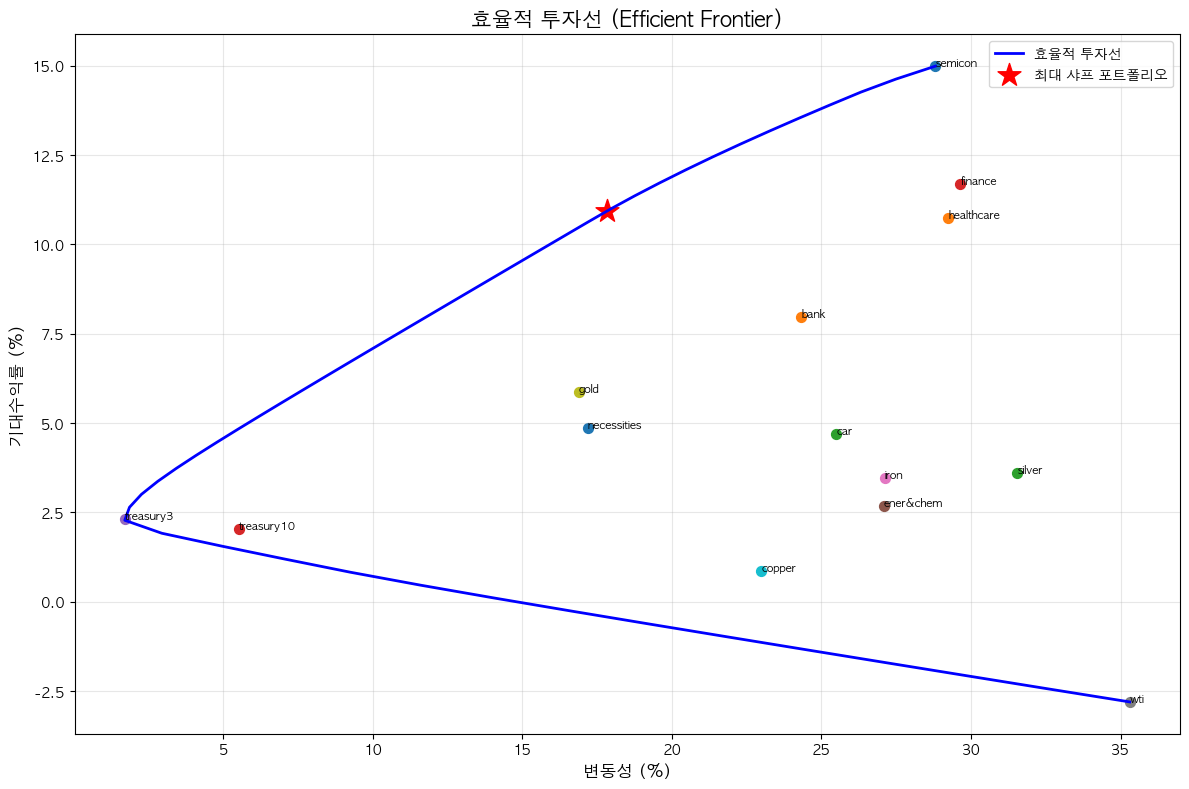


 모든 분석 완료!


In [9]:
# ==========================================
# 8. 효율적 투자선 (Efficient Frontier) 시각화
# ==========================================
print("\n[진행중] 효율적 투자선 그래프를 그리는 중입니다...")

target_returns = np.linspace(expected_returns_array.min(), expected_returns_array.max(), 50)
frontier_volatility = []

def minimize_volatility_for_target(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

frontier_bounds = tuple((0.0, 1.0) for _ in range(num_assets))

for target in target_returns:
    frontier_constraints = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0},
        {'type': 'eq', 'fun': lambda x, t=target: np.sum(x * expected_returns_array) - t}
    )

    result = sco.minimize(minimize_volatility_for_target, initial_weights, args=(cov_matrix.values,),
                          method='SLSQP', bounds=frontier_bounds, constraints=frontier_constraints)

    if result.success:
        frontier_volatility.append(np.sqrt(np.dot(result.x.T, np.dot(cov_matrix.values, result.x))))
    else:
        frontier_volatility.append(np.nan)

plt.figure(figsize=(12, 8))
plt.plot(np.array(frontier_volatility) * 100, target_returns * 100, 'b-', linewidth=2, label='효율적 투자선')
plt.scatter(port_vol * 100, port_ret * 100, color='red', marker='*', s=300, label='최대 샤프 포트폴리오')

# 개별 자산 표시
for i, asset in enumerate(assets):
    plt.scatter(asset_volatilities[i] * 100, expected_returns_array[i] * 100, s=50)
    plt.annotate(asset, (asset_volatilities[i] * 100, expected_returns_array[i] * 100), fontsize=8)

plt.xlabel('변동성 (%)', fontsize=12)
plt.ylabel('기대수익률 (%)', fontsize=12)
plt.title('효율적 투자선 (Efficient Frontier)', fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n 모든 분석 완료!")